<a href="https://colab.research.google.com/github/JoyNgaru/Decision-Trees-and-Ensemble-Methods/blob/main/Decision_Trees_%26_Ensemble_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving creditcard.csv to creditcard (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20 

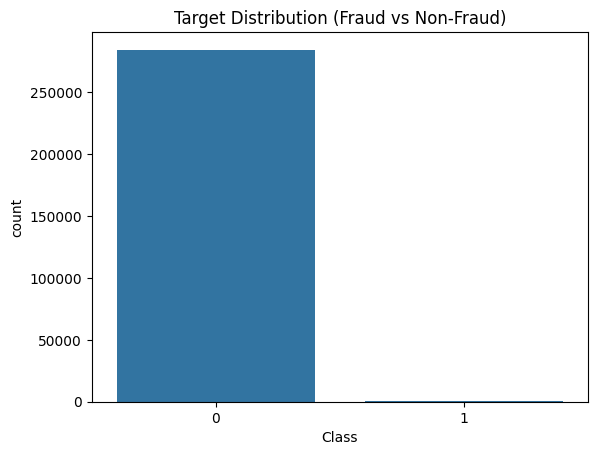


Decision Tree Results:
Accuracy: 0.9994557775359011
Precision: 0.8941176470588236
Recall: 0.7755102040816326
F1 Score: 0.8306010928961749

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.78      0.83        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56855     9]
 [   22    76]]

Random Forest Results:
Accuracy: 0.9995962220427653
Precision: 0.9411764705882353
Recall: 0.8163265306122449
F1 Score: 0.8743169398907104

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00

In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Step 2: Upload Dataset (Option 1: Manual Upload)
from google.colab import files
uploaded = files.upload()   # Upload creditcard.csv manually
df = pd.read_csv("creditcard.csv")

# Alternative Option 2: Kaggle API (if you have kaggle.json set up)
# !pip install kaggle
# !mkdir ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d mlg-ulb/creditcardfraud
# !unzip creditcardfraud.zip
# df = pd.read_csv("creditcard.csv")

# Explore dataset
print(df.info())
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Target Distribution (Fraud vs Non-Fraud)")
plt.show()

# Step 3: Preprocessing
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Utility function for evaluation
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 4: Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
evaluate_model("Decision Tree", dt, X_test, y_test)

# Step 5: Random Forest (Bagging)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
evaluate_model("Random Forest", rf, X_test, y_test)

# Step 6: AdaBoost (Boosting)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)
evaluate_model("AdaBoost", ada, X_test, y_test)

# Step 7: Stacking
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=5)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)
stack.fit(X_train, y_train)
evaluate_model("Stacking", stack, X_test, y_test)

# Step 8: Model Comparison Table
results = {
    "Decision Tree": [accuracy_score(y_test, dt.predict(X_test)),
                      precision_score(y_test, dt.predict(X_test)),
                      recall_score(y_test, dt.predict(X_test)),
                      f1_score(y_test, dt.predict(X_test))],
    "Random Forest": [accuracy_score(y_test, rf.predict(X_test)),
                      precision_score(y_test, rf.predict(X_test)),
                      recall_score(y_test, rf.predict(X_test)),
                      f1_score(y_test, rf.predict(X_test))],
    "AdaBoost": [accuracy_score(y_test, ada.predict(X_test)),
                 precision_score(y_test, ada.predict(X_test)),
                 recall_score(y_test, ada.predict(X_test)),
                 f1_score(y_test, ada.predict(X_test))],
    "Stacking": [accuracy_score(y_test, stack.predict(X_test)),
                 precision_score(y_test, stack.predict(X_test)),
                 recall_score(y_test, stack.predict(X_test)),
                 f1_score(y_test, stack.predict(X_test))]
}

comparison_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1 Score"])
print("\nModel Comparison:\n")
print(comparison_df)
